# HDFS Log Clustering Experiments — v2 (Preprocessed Features)

**Key change from v1:** We now cluster at the *incident level* using the preprocessed
`Event_occurrence_matrix.csv` instead of embedding individual raw log lines.
Each row = one block (incident). Ground truth = `Label` (Normal/Anomaly) + `Type` (failure mode).

### Experiment plan
1. Load & understand the feature matrix
2. Feature engineering (log-norm, binary, TF-IDF-style weighting)
3. Optionally augment with latency from `Event_traces.csv`
4. UMAP → HDBSCAN with hyperparameter sweep
5. Evaluate against Label AND Type (failure mode)
6. Visualise + qualitatively inspect clusters
7. Export cluster assignments for LLM summarisation step

---

## 0. Installs

In [ ]:
# !pip install hdbscan umap-learn scikit-learn pandas matplotlib seaborn

## 1. Imports & Config

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from pathlib import Path
from collections import Counter
from itertools import product as iterproduct

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_completeness_v_measure,
)

import hdbscan
import umap

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
RANDOM_STATE = 42

DATA_DIR    = Path("../../HDFS_v1/preprocessed")
OCC_FILE    = DATA_DIR / "Event_occurrence_matrix.csv"
TRACES_FILE = DATA_DIR / "Event_traces.csv"

print("Imports OK")

Imports OK


## 2. Load Data

In [2]:
occ = pd.read_csv(OCC_FILE)
EVENT_COLS = [c for c in occ.columns if c.startswith("E")]

print(f"Incidents : {len(occ):,}")
print(f"Event cols: {len(EVENT_COLS)}  ->  {EVENT_COLS}")
print(f"\nLabel distribution:")
print(occ["Label"].value_counts())
print(f"\nFailure Type distribution (Fail rows only, top 10):")
print(occ[occ["Label"]=="Fail"]["Type"].value_counts().head(10))

Incidents : 575,061
Event cols: 29  ->  ['E1', 'E2', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E20', 'E21', 'E22', 'E23', 'E24', 'E25', 'E26', 'E27', 'E28', 'E29']

Label distribution:
Label
Success    558223
Fail        16838
Name: count, dtype: int64

Failure Type distribution (Fail rows only, top 10):
Type
5.0     4167
31.0    3225
3.0     2950
0.0     2809
4.0     1240
1.0      953
21.0     724
7.0      476
12.0     130
8.0       45
Name: count, dtype: int64


In [3]:
# Load latency from traces and merge
traces = pd.read_csv(TRACES_FILE)
latency = traces[["BlockId", "Latency"]].copy()
latency["Latency"] = pd.to_numeric(latency["Latency"], errors="coerce")
occ = occ.merge(latency, on="BlockId", how="left")

print(f"Latency null rate: {occ['Latency'].isna().mean():.1%}")
print(f"\nLatency by label (ms):")
print(occ.groupby("Label")["Latency"].describe().round(0))

Latency null rate: 0.0%

Latency by label (ms):
            count     mean      std  min     25%     50%      75%      max
Label                                                                     
Fail      16838.0  14089.0  18377.0  0.0     3.0  4920.0  31718.0  53924.0
Success  558223.0  16871.0  17866.0  0.0  1241.0  7303.0  33732.0  54025.0


## 3. Feature Engineering

We test three representations of the event count matrix:

| Name | Transform | Rationale |
|---|---|---|
| `raw` | None | Baseline — but E3 dominates with up to 203x counts |
| `log1p` | `log(1 + count)` | Dampens high-frequency events (E3, E5) — **recommended** |
| `binary` | `count > 0` | Presence/absence only — ignores repetition |
| `log1p+lat` | log1p + log-scaled latency | Adds timing signal |

In [4]:
X_raw    = occ[EVENT_COLS].values.astype(np.float32)
X_log1p  = np.log1p(X_raw)
X_binary = (X_raw > 0).astype(np.float32)

# Latency as an extra normalised feature
lat_vals = occ["Latency"].fillna(occ["Latency"].median()).values.reshape(-1, 1)
lat_scaled = np.log1p(lat_vals).astype(np.float32)
lat_scaled = lat_scaled / lat_scaled.std()   # scale to event-feature range
X_log1p_lat = np.hstack([X_log1p, lat_scaled])

feature_sets = {
    "raw":       X_raw,
    "log1p":     X_log1p,
    "binary":    X_binary,
    "log1p+lat": X_log1p_lat,
}

print("Feature set shapes:")
for name, X in feature_sets.items():
    print(f"  {name:12s}: {X.shape}")

Feature set shapes:
  raw         : (575061, 29)
  log1p       : (575061, 29)
  binary      : (575061, 29)
  log1p+lat   : (575061, 30)


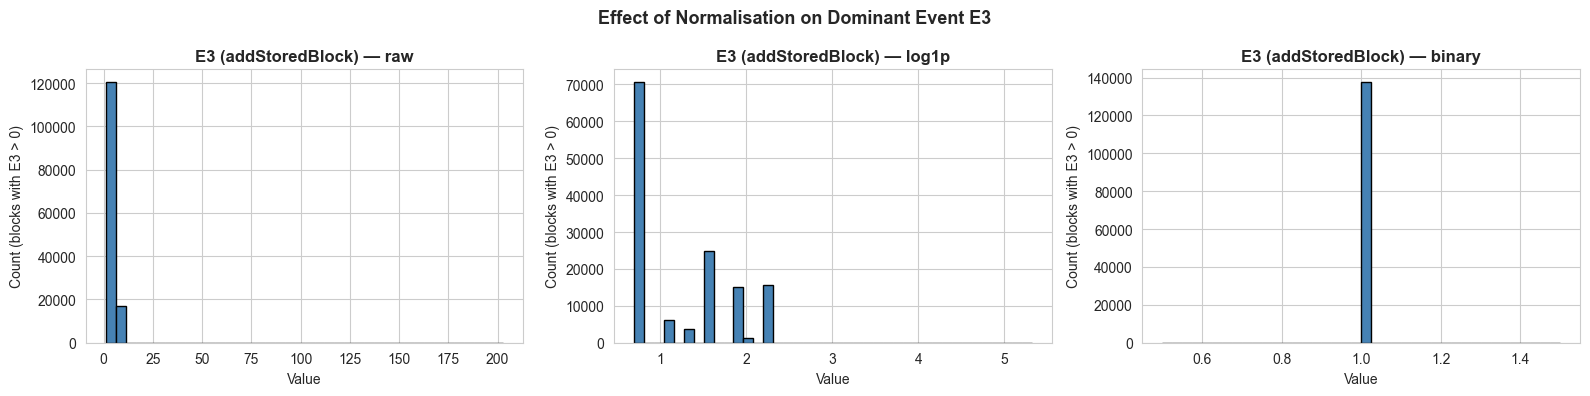

In [5]:
# Show the effect of normalisation on E3 (the dominant event)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
e3_idx = EVENT_COLS.index("E3")

for ax, (name, X) in zip(axes, [("raw",X_raw),("log1p",X_log1p),("binary",X_binary)]):
    vals = X[:, e3_idx]
    ax.hist(vals[vals > 0], bins=40, color="steelblue", edgecolor="black")
    ax.set_title(f"E3 (addStoredBlock) — {name}", fontweight="bold")
    ax.set_xlabel("Value")
    ax.set_ylabel("Count (blocks with E3 > 0)")

plt.suptitle("Effect of Normalisation on Dominant Event E3", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Ground Truth Encoding

Two levels of ground truth:
- **Binary** — `Label`: Normal vs Fail. Use for anomaly detection evaluation.
- **Fine-grained** — `Type`: failure mode code (26 distinct codes). Use for root-cause clustering evaluation.

A perfect clustering for the LLM pipeline would align with `Type` — each cluster is one
failure mode that the LLM can summarize coherently.

In [6]:
y_binary = (occ["Label"] == "Fail").astype(int).values

# Fine-grained: -1 for Normal, numeric code for failures
type_col_raw = occ["Type"].fillna(-1)
y_type = LabelEncoder().fit_transform(type_col_raw)

print(f"Binary labels   : {np.unique(y_binary)}  (0=Normal, 1=Anomaly)")
print(f"Type labels     : {len(np.unique(y_type))} distinct classes")
print(f"\nType breakdown (top 10):")
print(pd.Series(type_col_raw.values).value_counts().head(10))

Binary labels   : [0 1]  (0=Normal, 1=Anomaly)
Type labels     : 27 distinct classes

Type breakdown (top 10):
-1.0     558223
 5.0       4167
 31.0      3225
 3.0       2950
 0.0       2809
 4.0       1240
 1.0        953
 21.0       724
 7.0        476
 12.0       130
Name: count, dtype: int64


## 5. Stratified Subsampling

575k rows is large for UMAP + HDBSCAN during experiments.
We subsample keeping ALL anomaly incidents + a random Normal sample.
Scale up `SAMPLE_SIZE` (or remove subsampling) for final runs.

In [7]:
USE_FULL_DATASET = True  # Set True to run on all 575k incidents
SAMPLE_SIZE = 20_000      # Only used when USE_FULL_DATASET = False

if USE_FULL_DATASET:
    sample_idx = np.arange(len(occ))
    occ_s      = occ.reset_index(drop=True)
    y_bin_s    = y_binary
    y_type_s   = y_type
    type_s_raw = type_col_raw.values
    feature_sets_s = feature_sets

    print(f"Using full dataset: {len(occ_s):,} incidents")
    print(f"Anomaly rate: {y_bin_s.mean():.1%}")
else:
    fail_idx   = np.where(y_binary == 1)[0]
    normal_idx = np.where(y_binary == 0)[0]

    n_normal = min(SAMPLE_SIZE - len(fail_idx), len(normal_idx))
    rng = np.random.default_rng(RANDOM_STATE)
    normal_sample = rng.choice(normal_idx, size=n_normal, replace=False)

    sample_idx = np.concatenate([fail_idx, normal_sample])
    rng.shuffle(sample_idx)

    occ_s      = occ.iloc[sample_idx].reset_index(drop=True)
    y_bin_s    = y_binary[sample_idx]
    y_type_s   = y_type[sample_idx]
    type_s_raw = type_col_raw.values[sample_idx]
    feature_sets_s = {name: X[sample_idx] for name, X in feature_sets.items()}

    print(f"Using sampled dataset: {len(sample_idx):,} incidents")
    print(f"Anomaly rate: {y_bin_s.mean():.1%}  (full dataset: {y_binary.mean():.1%})")

Using full dataset: 575,061 incidents
Anomaly rate: 2.9%


In [52]:
from sklearn.preprocessing import LabelEncoder

# Reconstruct label encoder from full dataset
type_filled = occ['Type'].fillna(-1)
le_type = LabelEncoder()
le_type.fit(type_filled)

# Build mapping from encoded int -> human readable template
templates = pd.read_csv('../../HDFS_v1/preprocessed/HDFS.log_templates.csv')

def clean_template(t):
    return t.replace('[*]', '').replace('  ', ' ').strip()[:40]

event_to_template_clean = {
    row['EventId']: clean_template(row['EventTemplate']) 
    for _, row in templates.iterrows()
}

# Type float (5.0) -> "E5: Receiving block src: dest:"
type_float_to_label = {-1.0: 'Normal'}
for val in occ['Type'].dropna().unique():
    event_id = f"E{int(val)}"
    label = event_to_template_clean.get(event_id, f"Unknown {event_id}")
    type_float_to_label[val] = f"E{int(val)}: {label}"

# Encoded int (0-26) -> readable label
encoded_to_label = {
    i: type_float_to_label.get(cls, f"Type {cls}") 
    for i, cls in enumerate(le_type.classes_)
}

for k, v in sorted(encoded_to_label.items()):
    print(f"{k:3d} -> {v}")

  0 -> Normal
  1 -> E0: Unknown E0
  2 -> E1: Adding an already existing block
  3 -> E3: Served blockto
  4 -> E4: Got exception while servingto
  5 -> E5: Receiving blocksrc:dest:
  6 -> E7: writeBlockreceived exception
  7 -> E8: PacketResponderfor blockInterrupted
  8 -> E9: Received blockof sizefrom
  9 -> E10: PacketResponderException
 10 -> E11: PacketResponderfor blockterminating
 11 -> E12: :Exception writing blockto mirror
 12 -> E13: Receiving empty packet for block
 13 -> E16: :Transmitted blockto
 14 -> E17: :Failed to transfertogot
 15 -> E18: Starting thread to transfer blockto
 16 -> E19: Reopen Block
 17 -> E20: Unexpected error trying to delete blockB
 18 -> E21: Deleting blockfile
 19 -> E22: BLOCK* NameSystemallocateBlock:
 20 -> E23: BLOCK* NameSystemdelete:is added to inva
 21 -> E24: BLOCK* Removing blockfrom neededReplicat
 22 -> E25: BLOCK* askto replicateto
 23 -> E27: BLOCK* NameSystemaddStoredBlock: Redunda
 24 -> E28: BLOCK* NameSystemaddStoredBlock: addSt

## 6. UMAP Reduction

In [10]:
FEATURE_SET = "log1p"   # "raw" | "log1p" | "binary" | "log1p+lat"

X_s = feature_sets_s[FEATURE_SET]
print(f"Feature set: {FEATURE_SET}  shape={X_s.shape}")

print("Fitting UMAP 2D (visualisation)...")
X_2d = umap.UMAP(
    n_components=2, n_neighbors=30, min_dist=0.1,
    metric="euclidean", random_state=RANDOM_STATE,
).fit_transform(X_s)

print("Fitting UMAP 10D (clustering)...")
X_reduced = umap.UMAP(
    n_components=10, n_neighbors=30, min_dist=0.0,
    metric="euclidean", random_state=RANDOM_STATE,
).fit_transform(X_s)

print("UMAP done.")

Feature set: log1p  shape=(575061, 29)
Fitting UMAP 2D (visualisation)...


c:\Users\vindi\Desktop\Class Files\EC528 - Cloud Computing\LLM_Assisted_Incident_Summarization_and_Clustering_from_System_Logs\.venv311\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


: 

C:\Users\vindi\AppData\Local\Temp\ipykernel_34736\3806161048.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  pal = cm.get_cmap("tab20", 27)


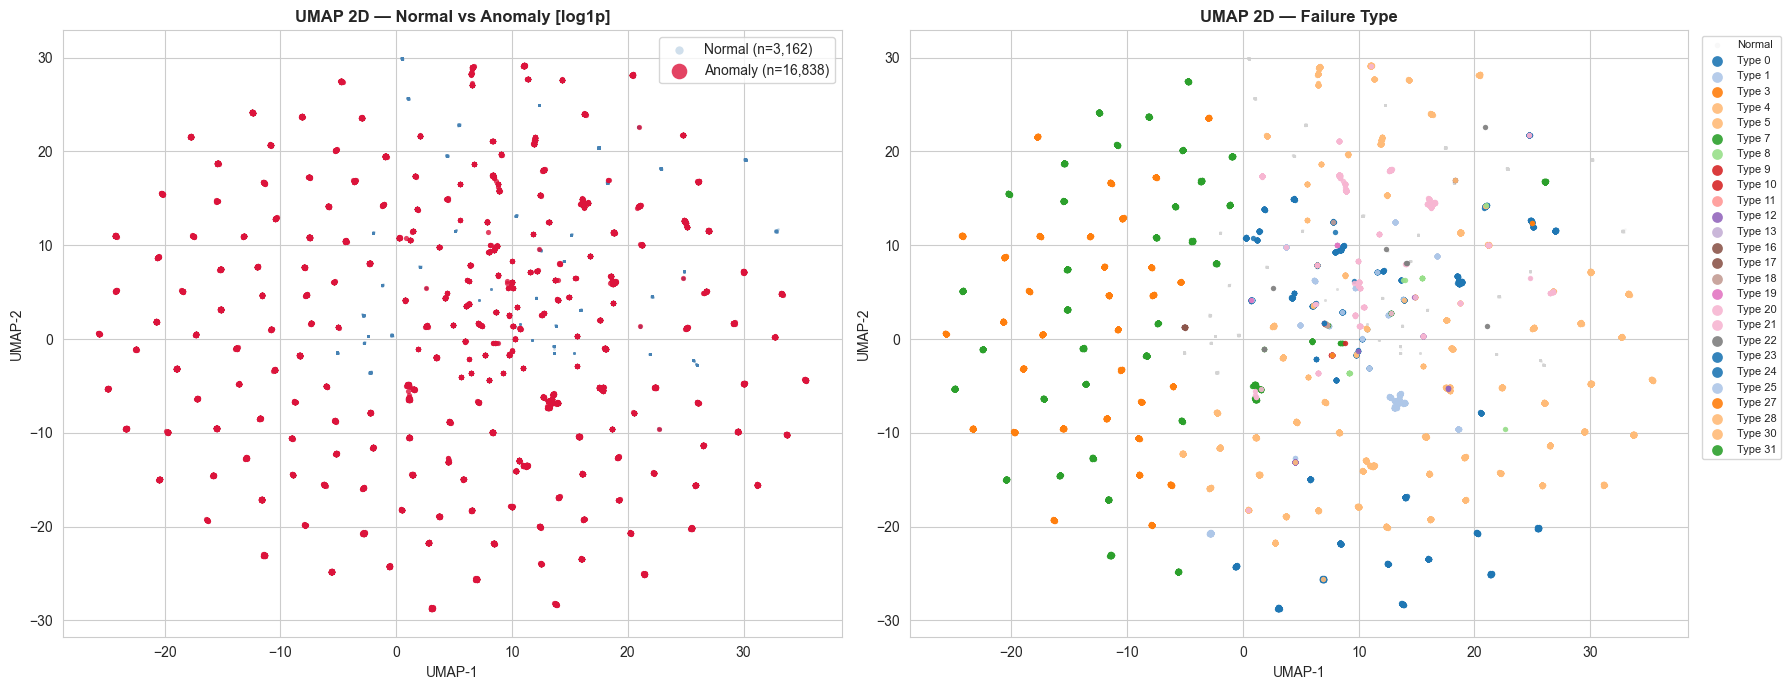

In [11]:
# Sanity check: do anomalies visually separate from normal?
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
pal = cm.get_cmap("tab20", 27)

ax = axes[0]
for val, color, name in [(0,"steelblue","Normal"),(1,"crimson","Anomaly")]:
    m = y_bin_s == val
    ax.scatter(X_2d[m,0], X_2d[m,1], c=color,
               s=4 if val==0 else 14, alpha=0.25 if val==0 else 0.8,
               label=f"{name} (n={m.sum():,})", linewidths=0)
ax.set_title(f"UMAP 2D — Normal vs Anomaly [{FEATURE_SET}]", fontweight="bold")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.legend(markerscale=3)

ax = axes[1]
for i, t in enumerate(np.unique(type_s_raw)):
    m = type_s_raw == t
    label = "Normal" if t == -1 else f"Type {int(t)}"
    color = "lightgray" if t == -1 else pal(i % 20)
    ax.scatter(X_2d[m,0], X_2d[m,1], c=[color],
               s=4 if t==-1 else 15, alpha=0.15 if t==-1 else 0.9,
               label=label, linewidths=0)
ax.set_title("UMAP 2D — Failure Type", fontweight="bold")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.legend(markerscale=2, bbox_to_anchor=(1.01,1), loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

## 7. Metric Helpers

In [8]:
def cluster_purity(y_true, y_pred):
    """Weighted purity excluding noise points (label == -1)."""
    mask = y_pred != -1
    if mask.sum() == 0:
        return 0.0
    lt, lp = y_true[mask], y_pred[mask]
    correct = sum(Counter(lt[lp == c]).most_common(1)[0][1] for c in np.unique(lp))
    return correct / mask.sum()


def anomaly_cluster_recall(y_binary, y_pred, threshold=0.9):
    """
    Fraction of anomalies landing in clusters where
    at least `threshold` fraction are anomalies.
    """
    anomaly_clusters = {
        c for c in np.unique(y_pred)
        if c != -1 and y_binary[y_pred == c].mean() >= threshold
    }
    true_anom = y_binary == 1
    if true_anom.sum() == 0:
        return 0.0
    return (true_anom & np.isin(y_pred, list(anomaly_clusters))).sum() / true_anom.sum()

def cluster_contamination_stats(y_binary, y_pred):
    """
    For each non-noise cluster, compute what fraction is anomalous.
    Returns mean and worst-case (min) anomaly fraction across clusters,
    and fraction of clusters that are 'pure' at various thresholds.
    """
    clusters = [c for c in np.unique(y_pred) if c != -1]
    anomaly_fracs = np.array([y_binary[y_pred == c].mean() for c in clusters])
    
    return {
        "mean_cluster_anomaly_frac": round(anomaly_fracs.mean(), 3),
        "pct_clusters_pure90":  round((anomaly_fracs >= 0.90).mean(), 3),  # 90%+ anomaly
        "pct_clusters_pure75":  round((anomaly_fracs >= 0.75).mean(), 3),  # 75%+ anomaly
        "pct_clusters_mixed":   round(((anomaly_fracs > 0.1) & (anomaly_fracs < 0.9)).mean(), 3),  # mixed clusters
        "pct_clusters_normal":  round((anomaly_fracs <= 0.1).mean(), 3),   # mostly normal
    }


def failure_type_fragmentation(y_type, y_pred):
    """
    For each failure type, count how many clusters it's spread across.
    High fragmentation = same root cause split into many clusters = bad for RCA.
    Returns mean and max fragmentation across failure types.
    """
    frags = []
    for t in np.unique(y_type):
        clusters_for_type = np.unique(y_pred[y_type == t])
        clusters_for_type = clusters_for_type[clusters_for_type != -1]
        frags.append(len(clusters_for_type))
    
    return {
        "mean_type_fragmentation": round(np.mean(frags), 2),
        "max_type_fragmentation":  round(np.max(frags), 2),
    }

def evaluate(y_binary, y_type, cluster_labels):
    """Full evaluation suite against both label granularities."""
    mask = cluster_labels != -1
    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    noise_frac  = (~mask).mean()

    if mask.sum() < 2 or n_clusters < 2:
        ari_bin = nmi_bin = ari_type = nmi_type = hom = com = vm = 0.0
    else:
        ari_bin  = adjusted_rand_score(y_binary[mask], cluster_labels[mask])
        nmi_bin  = normalized_mutual_info_score(y_binary[mask], cluster_labels[mask])
        ari_type = adjusted_rand_score(y_type[mask], cluster_labels[mask])
        nmi_type = normalized_mutual_info_score(y_type[mask], cluster_labels[mask])
        hom, com, vm = homogeneity_completeness_v_measure(y_type[mask], cluster_labels[mask])
        contam = cluster_contamination_stats(y_binary, cluster_labels)
        frag   = failure_type_fragmentation(y_type[mask], cluster_labels[mask])
    return {
        "n_clusters":     n_clusters,
        "noise_frac":     round(noise_frac, 3),
        "purity_binary":  round(cluster_purity(y_binary, cluster_labels), 3),
        "purity_type":    round(cluster_purity(y_type, cluster_labels), 3),
        "anomaly_recall_50":  round(anomaly_cluster_recall(y_binary, cluster_labels, 0.50), 3),
        "anomaly_recall_75":  round(anomaly_cluster_recall(y_binary, cluster_labels, 0.75), 3),
        "anomaly_recall_90":  round(anomaly_cluster_recall(y_binary, cluster_labels, 0.90), 3),
        "ari_binary":     round(ari_bin, 3),
        "nmi_binary":     round(nmi_bin, 3),
        "ari_type":       round(ari_type, 3),
        "nmi_type":       round(nmi_type, 3),
        "homogeneity":    round(hom, 3),
        "completeness":   round(com, 3),
        "v_measure":      round(vm, 3),
        **contam,
        **frag
    }

print("Metric helpers defined.")

Metric helpers defined.


## 8. HDBSCAN Hyperparameter Sweep

In [9]:
# min_cluster_size guide: dataset has 26 failure types, ~16k anomalies total
# In a 10k sample ~16k anomalies = all of them, so expect 26 possible anomaly clusters
# min_cluster_size around 16838/26 ~ 650 would give one cluster per type at full scale
# At 10k sample scale accordingly: ~16k/26 * (16k/575k) ratio -> try 10-200

#sampled parameter sweep
#param_grid = {
#    "min_cluster_size":         [10, 25, 50, 100, 200, 300, 400],
#    "min_samples":              [1, 5, 10, 20, 50],
#    "cluster_selection_method": ["eom", "leaf"],
#}

# full data parameter sweep
param_grid = {
    "min_cluster_size":         [300, 500, 648, 800, 1000, 1500],
    "min_samples":              [5, 20, 50],
    "cluster_selection_method": ["eom"],
}

X_features = feature_sets_s["log1p"] # Using UMAP first seems counterintuitive
results = []
clusterers = {}  # store fitted clusterers keyed by params

for combo in iterproduct(*param_grid.values()):
    params = dict(zip(param_grid.keys(), combo))
    
    clusterer = hdbscan.HDBSCAN(
        **params, metric="euclidean", core_dist_n_jobs=-1
    )
    labels = clusterer.fit_predict(X_features)  # store clusterer separately
    
    metrics = evaluate(y_bin_s, y_type_s, labels)
    results.append({**params, **metrics})
    
    # Store clusterer with a hashable key
    key = (params['min_cluster_size'], params['min_samples'], params['cluster_selection_method'])
    clusterers[key] = clusterer
    
    print(f"mcs={params['min_cluster_size']:3d} ms={params['min_samples']:2d} "
          f"{params['cluster_selection_method']:4s} -> "
          f"clusters={metrics['n_clusters']:3d}  "
          f"purity_type={metrics['purity_type']:.3f}  "
          f"anom_recall={metrics['anomaly_recall_90']:.3f}  "
          f"noise={metrics['noise_frac']:.2f}")

results_df = pd.DataFrame(results)
print(f"\nRan {len(results_df)} experiments.")

mcs=300 ms= 5 eom  -> clusters= 53  purity_type=0.999  anom_recall=0.865  noise=0.00
mcs=300 ms=20 eom  -> clusters= 53  purity_type=0.998  anom_recall=0.864  noise=0.00
mcs=300 ms=50 eom  -> clusters= 53  purity_type=0.998  anom_recall=0.863  noise=0.01
mcs=500 ms= 5 eom  -> clusters= 42  purity_type=0.999  anom_recall=0.794  noise=0.01
mcs=500 ms=20 eom  -> clusters= 42  purity_type=0.998  anom_recall=0.805  noise=0.01
mcs=500 ms=50 eom  -> clusters= 42  purity_type=0.999  anom_recall=0.798  noise=0.01
mcs=648 ms= 5 eom  -> clusters= 38  purity_type=0.997  anom_recall=0.806  noise=0.01


c:\Users\vindi\Desktop\Class Files\EC528 - Cloud Computing\LLM_Assisted_Incident_Summarization_and_Clustering_from_System_Logs\.venv311\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


mcs=648 ms=20 eom  -> clusters= 38  purity_type=0.998  anom_recall=0.805  noise=0.01
mcs=648 ms=50 eom  -> clusters= 38  purity_type=0.997  anom_recall=0.800  noise=0.01
mcs=800 ms= 5 eom  -> clusters= 35  purity_type=0.998  anom_recall=0.759  noise=0.01
mcs=800 ms=20 eom  -> clusters= 34  purity_type=0.998  anom_recall=0.759  noise=0.01
mcs=800 ms=50 eom  -> clusters= 33  purity_type=0.998  anom_recall=0.761  noise=0.01
mcs=1000 ms= 5 eom  -> clusters= 30  purity_type=0.998  anom_recall=0.761  noise=0.01


c:\Users\vindi\Desktop\Class Files\EC528 - Cloud Computing\LLM_Assisted_Incident_Summarization_and_Clustering_from_System_Logs\.venv311\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


mcs=1000 ms=20 eom  -> clusters= 29  purity_type=0.998  anom_recall=0.761  noise=0.01
mcs=1000 ms=50 eom  -> clusters= 29  purity_type=0.998  anom_recall=0.761  noise=0.01
mcs=1500 ms= 5 eom  -> clusters= 24  purity_type=0.997  anom_recall=0.761  noise=0.01
mcs=1500 ms=20 eom  -> clusters= 24  purity_type=0.998  anom_recall=0.761  noise=0.01
mcs=1500 ms=50 eom  -> clusters= 24  purity_type=0.998  anom_recall=0.761  noise=0.01

Ran 18 experiments.


In [12]:
results_df.sort_values("purity_type", ascending=False)
# results_df.to_csv('clustering_results.csv')

,min_cluster_size,min_samples,cluster_selection_method,n_clusters,noise_frac,purity_binary,purity_type,anomaly_recall_50,anomaly_recall_75,anomaly_recall_90,...,homogeneity,completeness,v_measure,mean_cluster_anomaly_frac,pct_clusters_pure90,pct_clusters_pure75,pct_clusters_mixed,pct_clusters_normal,mean_type_fragmentation,max_type_fragmentation
0,300,5,eom,53,0.004,0.999,0.999,0.915,0.884,0.865,...,0.976,0.088,0.161,0.274,0.245,0.264,0.038,0.717,4.82,43
3,500,5,eom,42,0.007,1.000,0.999,0.825,0.794,0.794,...,0.978,0.080,0.148,0.208,0.190,0.190,0.024,0.786,3.82,36
5,500,50,eom,42,0.006,1.000,0.999,0.829,0.798,0.798,...,0.976,0.080,0.149,0.208,0.190,0.190,0.024,0.786,4.12,36
1,300,20,eom,53,0.004,0.999,0.998,0.914,0.883,0.864,...,0.965,0.087,0.160,0.274,0.245,0.264,0.038,0.717,5.00,43
2,300,50,eom,53,0.005,0.999,0.998,0.915,0.884,0.863,...,0.975,0.088,0.161,0.275,0.245,0.264,0.038,0.717,4.88,42
4,500,20,eom,42,0.006,0.999,0.998,0.837,0.805,0.805,...,0.965,0.081,0.149,0.208,0.190,0.190,0.024,0.786,4.24,36
7,648,20,eom,38,0.007,0.999,0.998,0.837,0.805,0.805,...,0.948,0.079,0.146,0.177,0.158,0.158,0.026,0.816,3.82,33
9,800,5,eom,35,0.010,0.999,0.998,0.759,0.759,0.759,...,0.920,0.072,0.134,0.143,0.143,0.143,0.000,0.857,3.35,31
11,800,50,eom,33,0.010,0.999,0.998,0.761,0.761,0.761,...,0.915,0.073,0.134,0.121,0.121,0.121,0.000,0.879,3.41,30
10,800,20,eom,34,0.011,1.000,0.998,0.759,0.759,0.759,...,0.952,0.072,0.135,0.147,0.147,0.147,0.000,0.853,3.35,30


In [ ]:
def rca_score(row):
    return (
        0.35 * row['anomaly_recall_90']      # most important - finding anomalies
      + 0.25 * row['pct_clusters_pure90']    # cluster trustworthiness
      + 0.20 * (1 - row['noise_frac'])       # coverage
      + 0.10 * (1 - row['pct_clusters_mixed']) # penalize mixed clusters
      + 0.10 * (1 - np.log1p(row['mean_type_fragmentation']) / 
                    np.log1p(results_df['mean_type_fragmentation'].max()))  # normalized fragmentation penalty
    )

results_df['rca_score'] = results_df.apply(rca_score, axis=1)
best = results_df.loc[results_df['rca_score'].idxmax()]
print(best)
best_key = (int(best['min_cluster_size']), int(best['min_samples']), best['cluster_selection_method'])

min_cluster_size                300
min_samples                       5
cluster_selection_method        eom
n_clusters                       53
noise_frac                    0.004
purity_binary                 0.999
purity_type                   0.999
anomaly_recall_50             0.915
anomaly_recall_75             0.884
anomaly_recall_90             0.865
ari_binary                    0.049
nmi_binary                    0.118
ari_type                      0.049
nmi_type                      0.161
homogeneity                   0.976
completeness                  0.088
v_measure                     0.161
mean_cluster_anomaly_frac     0.274
pct_clusters_pure90           0.245
pct_clusters_pure75           0.264
pct_clusters_mixed            0.038
pct_clusters_normal           0.717
mean_type_fragmentation        4.82
max_type_fragmentation           43
rca_score                    0.6611
Name: 0, dtype: object


## fragmentation investigation

In [15]:
# First, decode your type labels to understand fragmentation
# Add this cell after your best config selection:

# Decode the type labels to understand which types are fragmenting
best_clusterer = clusterers[best_key]
best_labels = best_clusterer.fit_predict(X_features)

type_decoder = dict(enumerate(LabelEncoder().fit(occ['Type'].fillna(-1)).classes_))
# Or simpler: create a mapping
type_names = {}
for idx, val in enumerate(np.unique(y_type_s)):
    if val == -1:  # Normal
        type_names[val] = "Normal"
    else:
        # Get original type value
        orig_type = type_col_raw.values[sample_idx][y_type_s == val][0]
        type_names[val] = f"Type_{orig_type}"

# Now analyze fragmentation with readable labels
frag_by_type = {}
type_samples = {}

for t in np.unique(y_type_s):
    mask = y_type_s == t
    clusters_for_type = best_labels[mask]
    clusters_for_type = clusters_for_type[clusters_for_type != -1]
    frag_by_type[t] = len(np.unique(clusters_for_type))
    type_samples[t] = mask.sum()

# Sort and show top fragmenting types
print("=== Most Fragmented Failure Types ===\n")
frag_list = [(type_names[t], frag_by_type[t], type_samples[t]) 
             for t in frag_by_type.keys() if t != -1]
frag_list.sort(key=lambda x: x[1], reverse=True)

for type_name, n_clusters, n_samples in frag_list[:10]:
    print(f"{type_name:20s}: {n_clusters:3d} clusters / {n_samples:4d} samples "
          f"({n_clusters/n_samples:.2f} clusters per sample)")

# Also check if some types are being missed entirely
missing_types = [type_names[t] for t in np.unique(y_type_s) 
                 if t != -1 and t not in frag_by_type]
if missing_types:
    print(f"\n⚠️ Types with NO clusters (all noise): {missing_types[:10]}")

=== Most Fragmented Failure Types ===

Type_-1.0           :  43 clusters / 558223 samples (0.00 clusters per sample)
Type_0.0            :   8 clusters / 2809 samples (0.00 clusters per sample)
Type_1.0            :   5 clusters /  953 samples (0.01 clusters per sample)
Type_5.0            :   5 clusters / 4167 samples (0.00 clusters per sample)
Type_21.0           :   5 clusters /  724 samples (0.01 clusters per sample)
Type_4.0            :   2 clusters / 1240 samples (0.00 clusters per sample)
Type_12.0           :   2 clusters /  130 samples (0.02 clusters per sample)
Type_18.0           :   2 clusters /    9 samples (0.22 clusters per sample)
Type_19.0           :   2 clusters /    8 samples (0.25 clusters per sample)
Type_3.0            :   1 clusters / 2950 samples (0.00 clusters per sample)


### fragmentation inv continued - type 5

In [18]:
# Focus on Type_5.0 - the most fragmented type
type_5_mask = y_type_s == 0  # Adjust if your encoding is different
type_5_clusters = best_labels[type_5_mask]
type_5_clusters = type_5_clusters[type_5_clusters != -1]

# See how Type_5.0 is distributed across clusters
unique_clusters, counts = np.unique(type_5_clusters, return_counts=True)
print(f"Type_0.0 spreads across {len(unique_clusters)} clusters")
print(f"Cluster sizes for Type_5.0: {counts}")
print(f"Small clusters (<10 samples): {(counts < 10).sum()}")

# Check if these clusters are pure or mixed
for cid in unique_clusters[:5]:  # Check first 5 clusters
    cluster_mask = best_labels == cid
    cluster_size = cluster_mask.sum()
    type_dist = pd.Series(y_type_s[cluster_mask]).value_counts()
    print(f"\nCluster {cid} (size={cluster_size}):")
    for t, count in type_dist.head(3).items():
        type_name = "Normal" if t == -1 else f"Type_{t}"
        print(f"  {type_name}: {count}")

Type_0.0 spreads across 43 clusters
Cluster sizes for Type_5.0: [ 96317   5575    348   1305   1537   1311    455    649     19     73
  19370   1098    197      3      4 300395   4405   1172    600   1890
    580    814   1398  21139    328  18710    866    930  11104   9488
   1069  16346   1117    744    904   5306    354    396  12664    941
  12841    993   1344]
Small clusters (<10 samples): 2

Cluster 3 (size=96317):
  Type_0: 96317

Cluster 4 (size=5575):
  Type_0: 5575

Cluster 5 (size=359):
  Type_0: 348
  Type_9: 3
  Type_16: 2

Cluster 6 (size=1321):
  Type_0: 1305
  Type_15: 8
  Type_2: 6

Cluster 10 (size=1537):
  Type_0: 1537


## Plotting

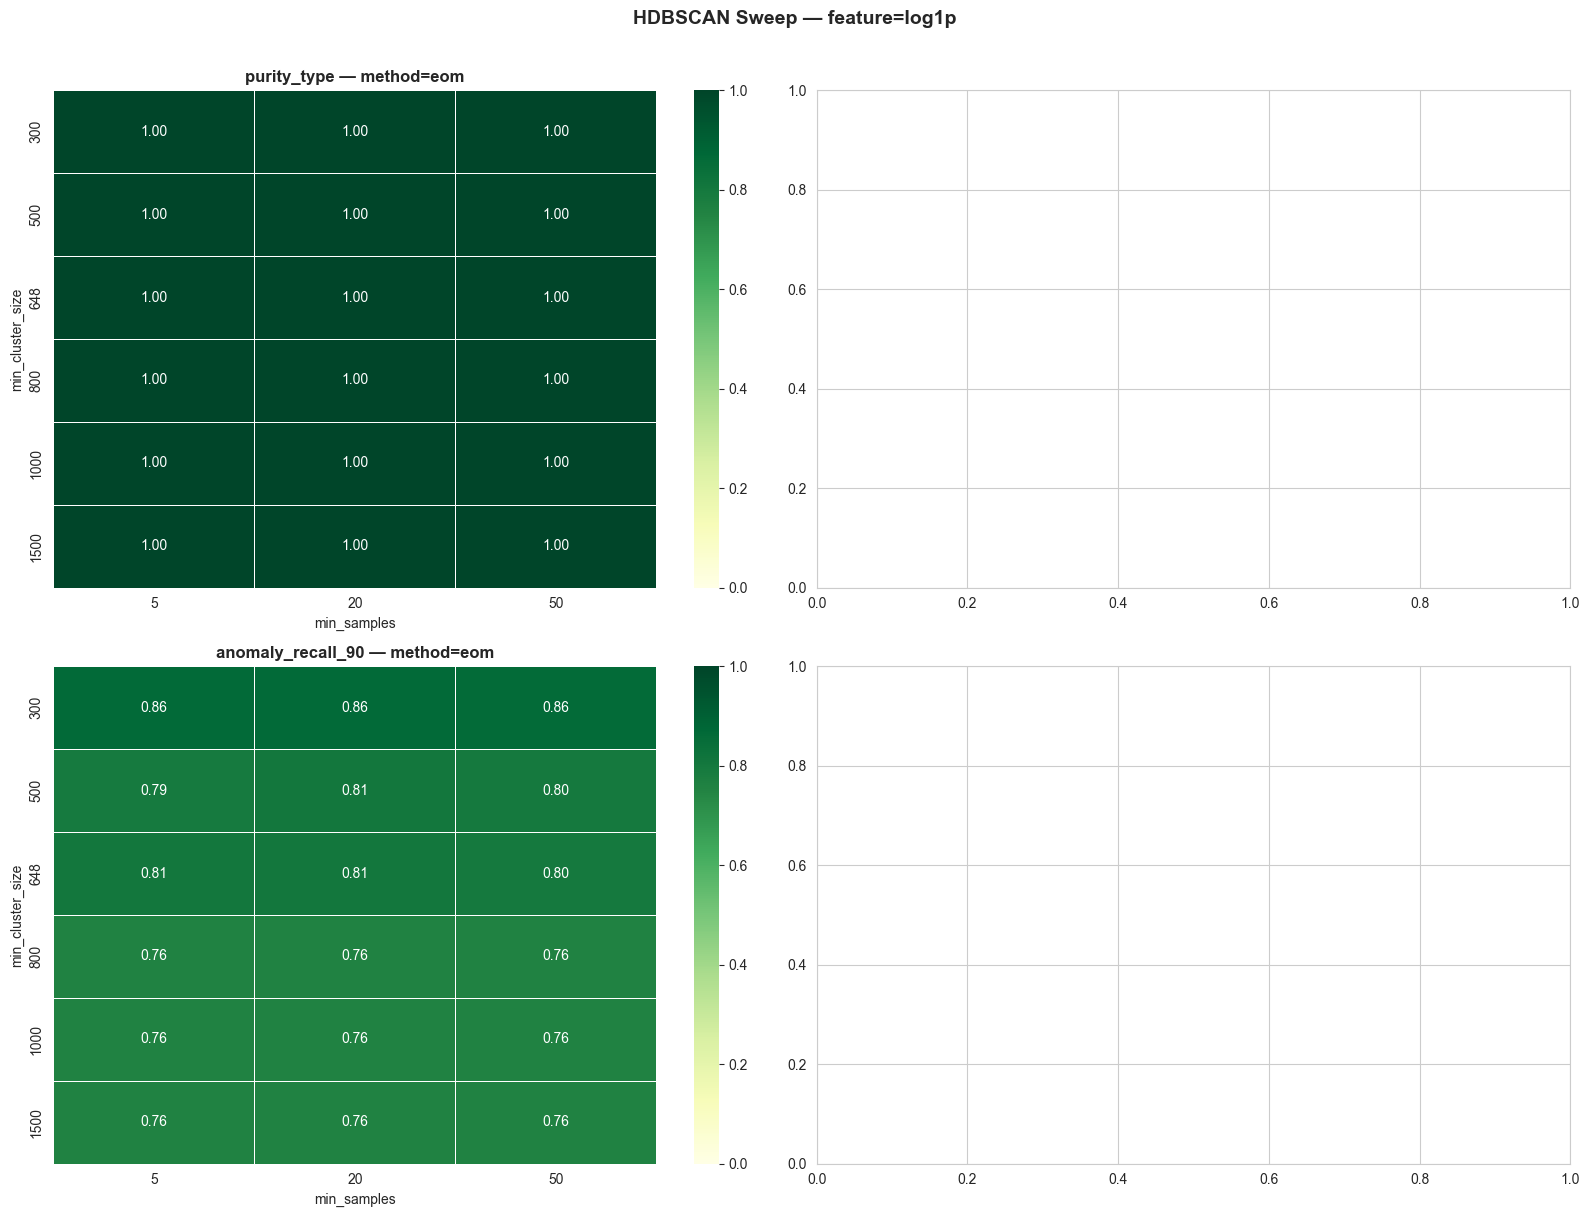

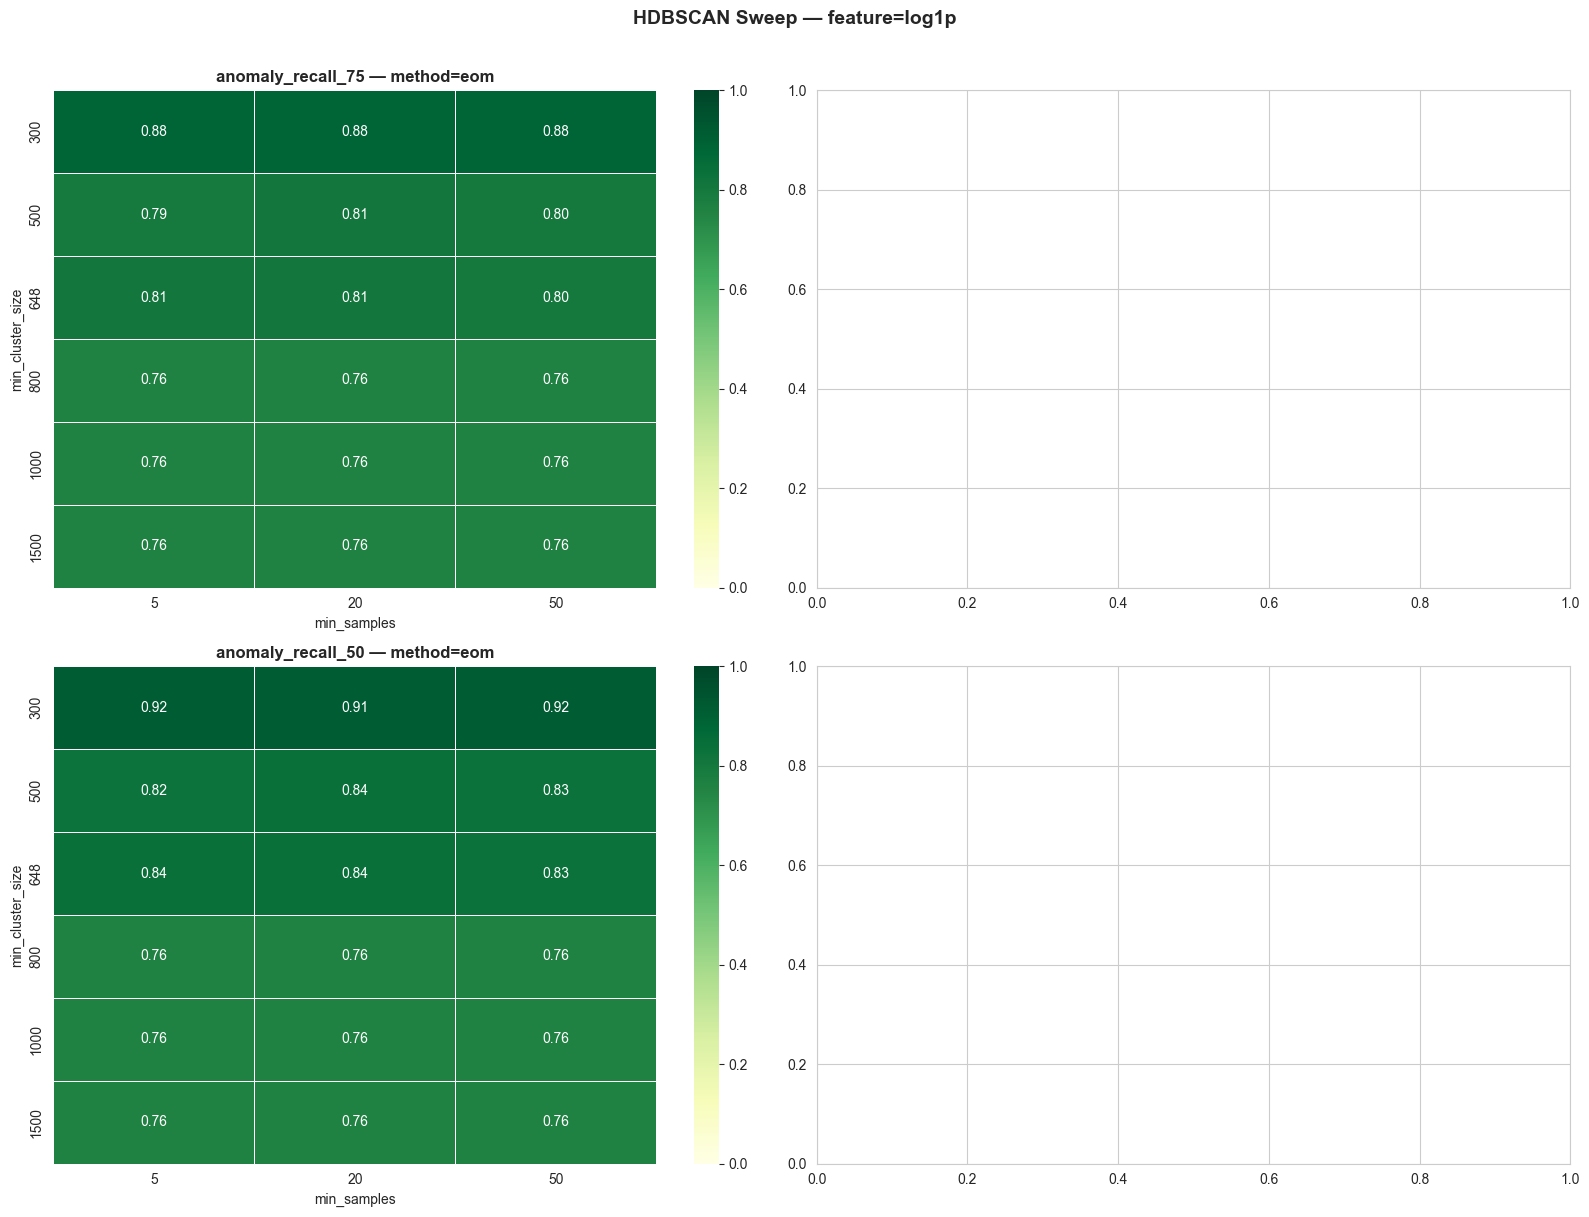

In [21]:
FEATURE_SET = "log1p"
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for col_idx, method in enumerate(["eom"]):
    sub = results_df[results_df["cluster_selection_method"] == method]
    for row_idx, metric in enumerate(["purity_type", "anomaly_recall_90"]):
        ax = axes[row_idx][col_idx]
        pivot = sub.pivot_table(index="min_cluster_size", columns="min_samples", values=metric)
        sns.heatmap(pivot, ax=ax, annot=True, fmt=".2f",
                    cmap="YlGn", vmin=0, vmax=1, linewidths=0.5)
        ax.set_title(f"{metric} — method={method}", fontweight="bold")
        ax.set_xlabel("min_samples")
        ax.set_ylabel("min_cluster_size")

plt.suptitle(f"HDBSCAN Sweep — feature={FEATURE_SET}", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for col_idx, method in enumerate(["eom"]):
    sub = results_df[results_df["cluster_selection_method"] == method]
    for row_idx, metric in enumerate(["anomaly_recall_75", "anomaly_recall_50"]):
        ax = axes[row_idx][col_idx]
        pivot = sub.pivot_table(index="min_cluster_size", columns="min_samples", values=metric)
        sns.heatmap(pivot, ax=ax, annot=True, fmt=".2f",
                    cmap="YlGn", vmin=0, vmax=1, linewidths=0.5)
        ax.set_title(f"{metric} — method={method}", fontweight="bold")
        ax.set_xlabel("min_samples")
        ax.set_ylabel("min_cluster_size")

plt.suptitle(f"HDBSCAN Sweep — feature={FEATURE_SET}", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Evaluating Through the Tree Heirarchy

In [23]:
def evaluate_tree_levels(clusterer, y_binary, y_type,
                         cut_levels=None, min_cluster_size=10):
    """
    Evaluate clustering quality at multiple cut-distance levels of the
    HDBSCAN single linkage tree. cut_levels are distance thresholds —
    smaller = more clusters (finer), larger = fewer clusters (coarser).
    Use the diagnostic block to pick meaningful values for your data.
    """
    if cut_levels is None:
        cut_levels = [0.02, 0.05, 0.1, 0.2, 0.5, 1.0]

    single_tree = clusterer.single_linkage_tree_
    level_results = []

    for cut in cut_levels:
        labels = single_tree.get_clusters(cut, min_cluster_size=min_cluster_size)
        metrics = evaluate(y_binary, y_type, labels)
        metrics['cut_distance'] = cut
        level_results.append(metrics)

    levels_df = pd.DataFrame(level_results).set_index('cut_distance')

    max_frag = levels_df['mean_type_fragmentation'].max()
    levels_df['rca_score'] = levels_df.apply(
        lambda row: (
            0.35 * row['anomaly_recall_90']
          + 0.25 * row['pct_clusters_pure90']
          + 0.20 * (1 - row['noise_frac'])
          + 0.10 * (1 - row['pct_clusters_mixed'])
          + 0.10 * (1 - np.log1p(row['mean_type_fragmentation']) /
                        np.log1p(max_frag + 1e-9))
        ),
        axis=1
    ).round(4)

    display_cols = [
        'n_clusters', 'rca_score', 'purity_type',
        'anomaly_recall_90', 'noise_frac',
        'mean_type_fragmentation', 'pct_clusters_pure90', 'pct_clusters_mixed'
    ]
    print(levels_df[display_cols].to_string())
    return levels_df


levels_df = evaluate_tree_levels(
    best_clusterer, y_bin_s, y_type_s,
    cut_levels=[0.02, 0.05, 0.1, 0.2, 0.3,0.4,0.5, 0.6, 0.7, 0.8, 0.9 ,1.0],
    min_cluster_size=10,
)

              n_clusters  rca_score  purity_type  anomaly_recall_90  noise_frac  mean_type_fragmentation  pct_clusters_pure90  pct_clusters_mixed
cut_distance                                                                                                                                     
0.02                 182     0.7503        1.000              0.958       0.002                    15.83                0.462               0.005
0.05                 184     0.7487        1.000              0.958       0.002                    16.00                0.457               0.005
0.10                 179     0.7524        1.000              0.958       0.002                    15.58                0.469               0.006
0.20                 157     0.7663        1.000              0.960       0.001                    14.33                0.510               0.006
0.30                 110     0.7978        0.999              0.942       0.001                     9.13                0.61

In [26]:
best_row = results_df.loc[results_df['rca_score'].idxmax()]
best_labels = best_clusterer.fit_predict(X_features)
occ_s["cluster"] = best_labels

print(f"\nClustered: {(best_labels != -1).sum():,} incidents across "
      f"{int(best_row['n_clusters'])} clusters")
print(f"Noise    : {(best_labels == -1).sum():,} unclustered")


Clustered: 572,530 incidents across 53 clusters
Noise    : 2,531 unclustered


C:\Users\vindi\AppData\Local\Temp\ipykernel_35952\1064410509.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  pal = cm.get_cmap("tab20", max(n_c, 1))


NameError: name 'X_2d' is not defined

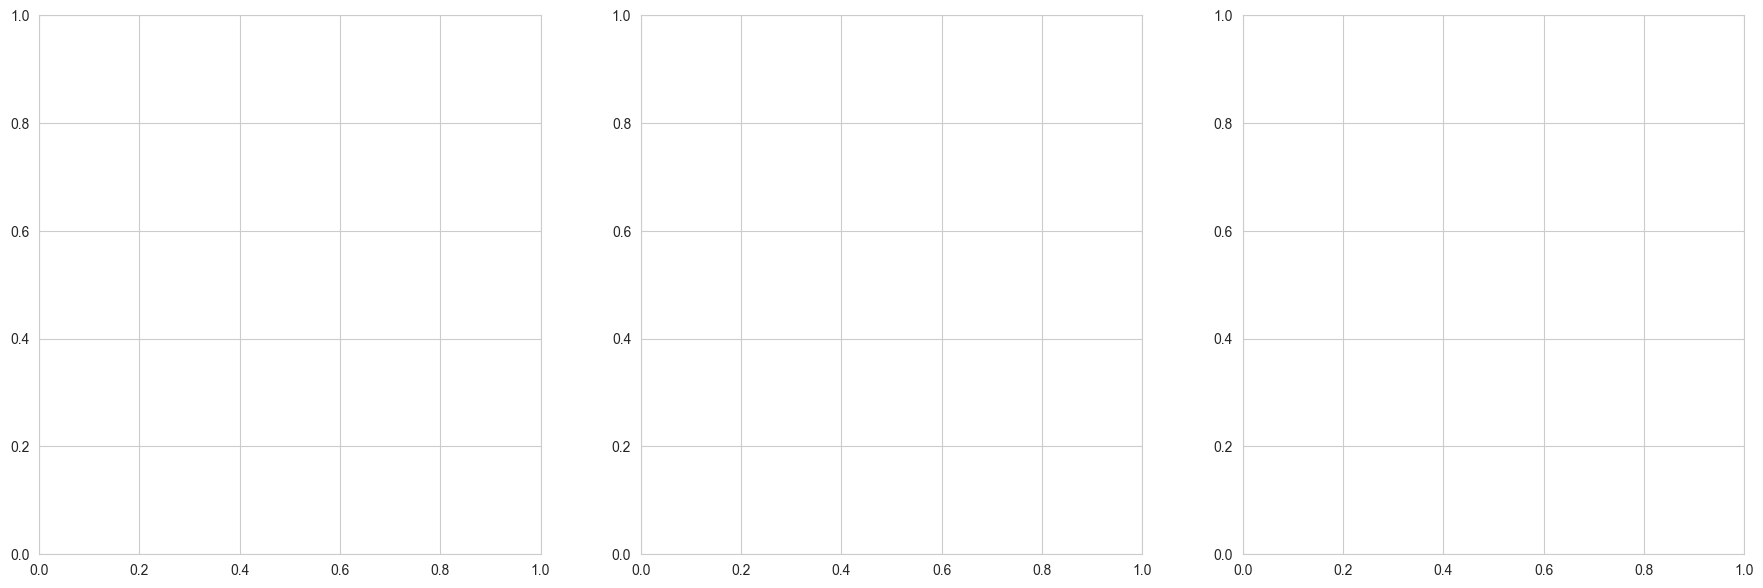

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(22, 7))
n_c = int(best_row["n_clusters"])
pal = cm.get_cmap("tab20", max(n_c, 1))

# Clusters
ax = axes[0]
for cid in sorted(occ_s["cluster"].unique()):
    m = occ_s["cluster"] == cid
    c = "lightgray" if cid==-1 else pal(cid % 20)
    ax.scatter(X_2d[m,0], X_2d[m,1], c=[c], s=6, alpha=0.5,
               label=("Noise" if cid==-1 else f"C{cid}"), linewidths=0)
ax.set_title("HDBSCAN Clusters", fontweight="bold")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
if n_c <= 20:
    ax.legend(markerscale=2, bbox_to_anchor=(1.01,1), loc="upper left", fontsize=7)

# Normal vs Anomaly
ax = axes[1]
for val, col, lbl in [(0,"steelblue","Normal"),(1,"crimson","Anomaly")]:
    m = y_bin_s == val
    ax.scatter(X_2d[m,0], X_2d[m,1], c=col,
               s=4 if val==0 else 14, alpha=0.25 if val==0 else 0.85,
               label=lbl, linewidths=0)
ax.set_title("Ground Truth — Normal / Anomaly", fontweight="bold")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.legend(markerscale=3)

# Failure type
ax = axes[2]
for i, t in enumerate(np.unique(type_s_raw)):
    m = type_s_raw == t
    lbl = "Normal" if t==-1 else f"Type {int(t)}"
    col = "lightgray" if t==-1 else pal(i % 20)
    ax.scatter(X_2d[m,0], X_2d[m,1], c=[col],
               s=4 if t==-1 else 15, alpha=0.15 if t==-1 else 0.9,
               label=lbl, linewidths=0)
ax.set_title("Ground Truth — Failure Type", fontweight="bold")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.legend(markerscale=2, bbox_to_anchor=(1.01,1), loc="upper left", fontsize=7)

plt.suptitle(f"UMAP 2D — feature={FEATURE_SET}, best HDBSCAN",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [29]:
# Per-cluster breakdown table
cluster_stats = []
for cid in sorted(occ_s["cluster"].unique()):
    if cid == -1:
        continue
    sub = occ_s[occ_s["cluster"] == cid]
    n = len(sub)
    n_anom      = (sub["Label"] == "Fail").sum()
    type_vc     = sub["Type"].value_counts(dropna=False)
    dom_type    = type_vc.index[0]
    type_purity = type_vc.iloc[0] / n
    cluster_stats.append({
        "cluster":      cid,
        "size":         n,
        "n_anomaly":    n_anom,
        "anomaly_frac": round(n_anom / n, 3),
        "dominant_type":str(dom_type),
        "type_purity":  round(type_purity, 3),
    })

cs_df = pd.DataFrame(cluster_stats).sort_values("anomaly_frac", ascending=False)
print(cs_df.to_string(index=False))
cs_df.to_csv("clustering_results_cluster_breakdown.csv")

 cluster   size  n_anomaly  anomaly_frac dominant_type  type_purity
       0   3231       3231         1.000          31.0        0.998
       1   2950       2950         1.000           3.0        1.000
       2    384        384         1.000           7.0        0.987
       7    785        785         1.000           4.0        0.999
       8    399        399         1.000           4.0        1.000
      11   3285       3285         1.000           5.0        0.969
       9    818        818         1.000           0.0        0.989
      23    445        445         1.000           0.0        1.000
      22    430        430         1.000           0.0        1.000
      24    536        536         1.000           1.0        1.000
      20    559        556         0.995           5.0        0.832
      21    336        332         0.988           0.0        0.988
      15    432        413         0.956          21.0        0.815
      16    389        316         0.812        

### 10.1 Event Profile Heatmap per Cluster

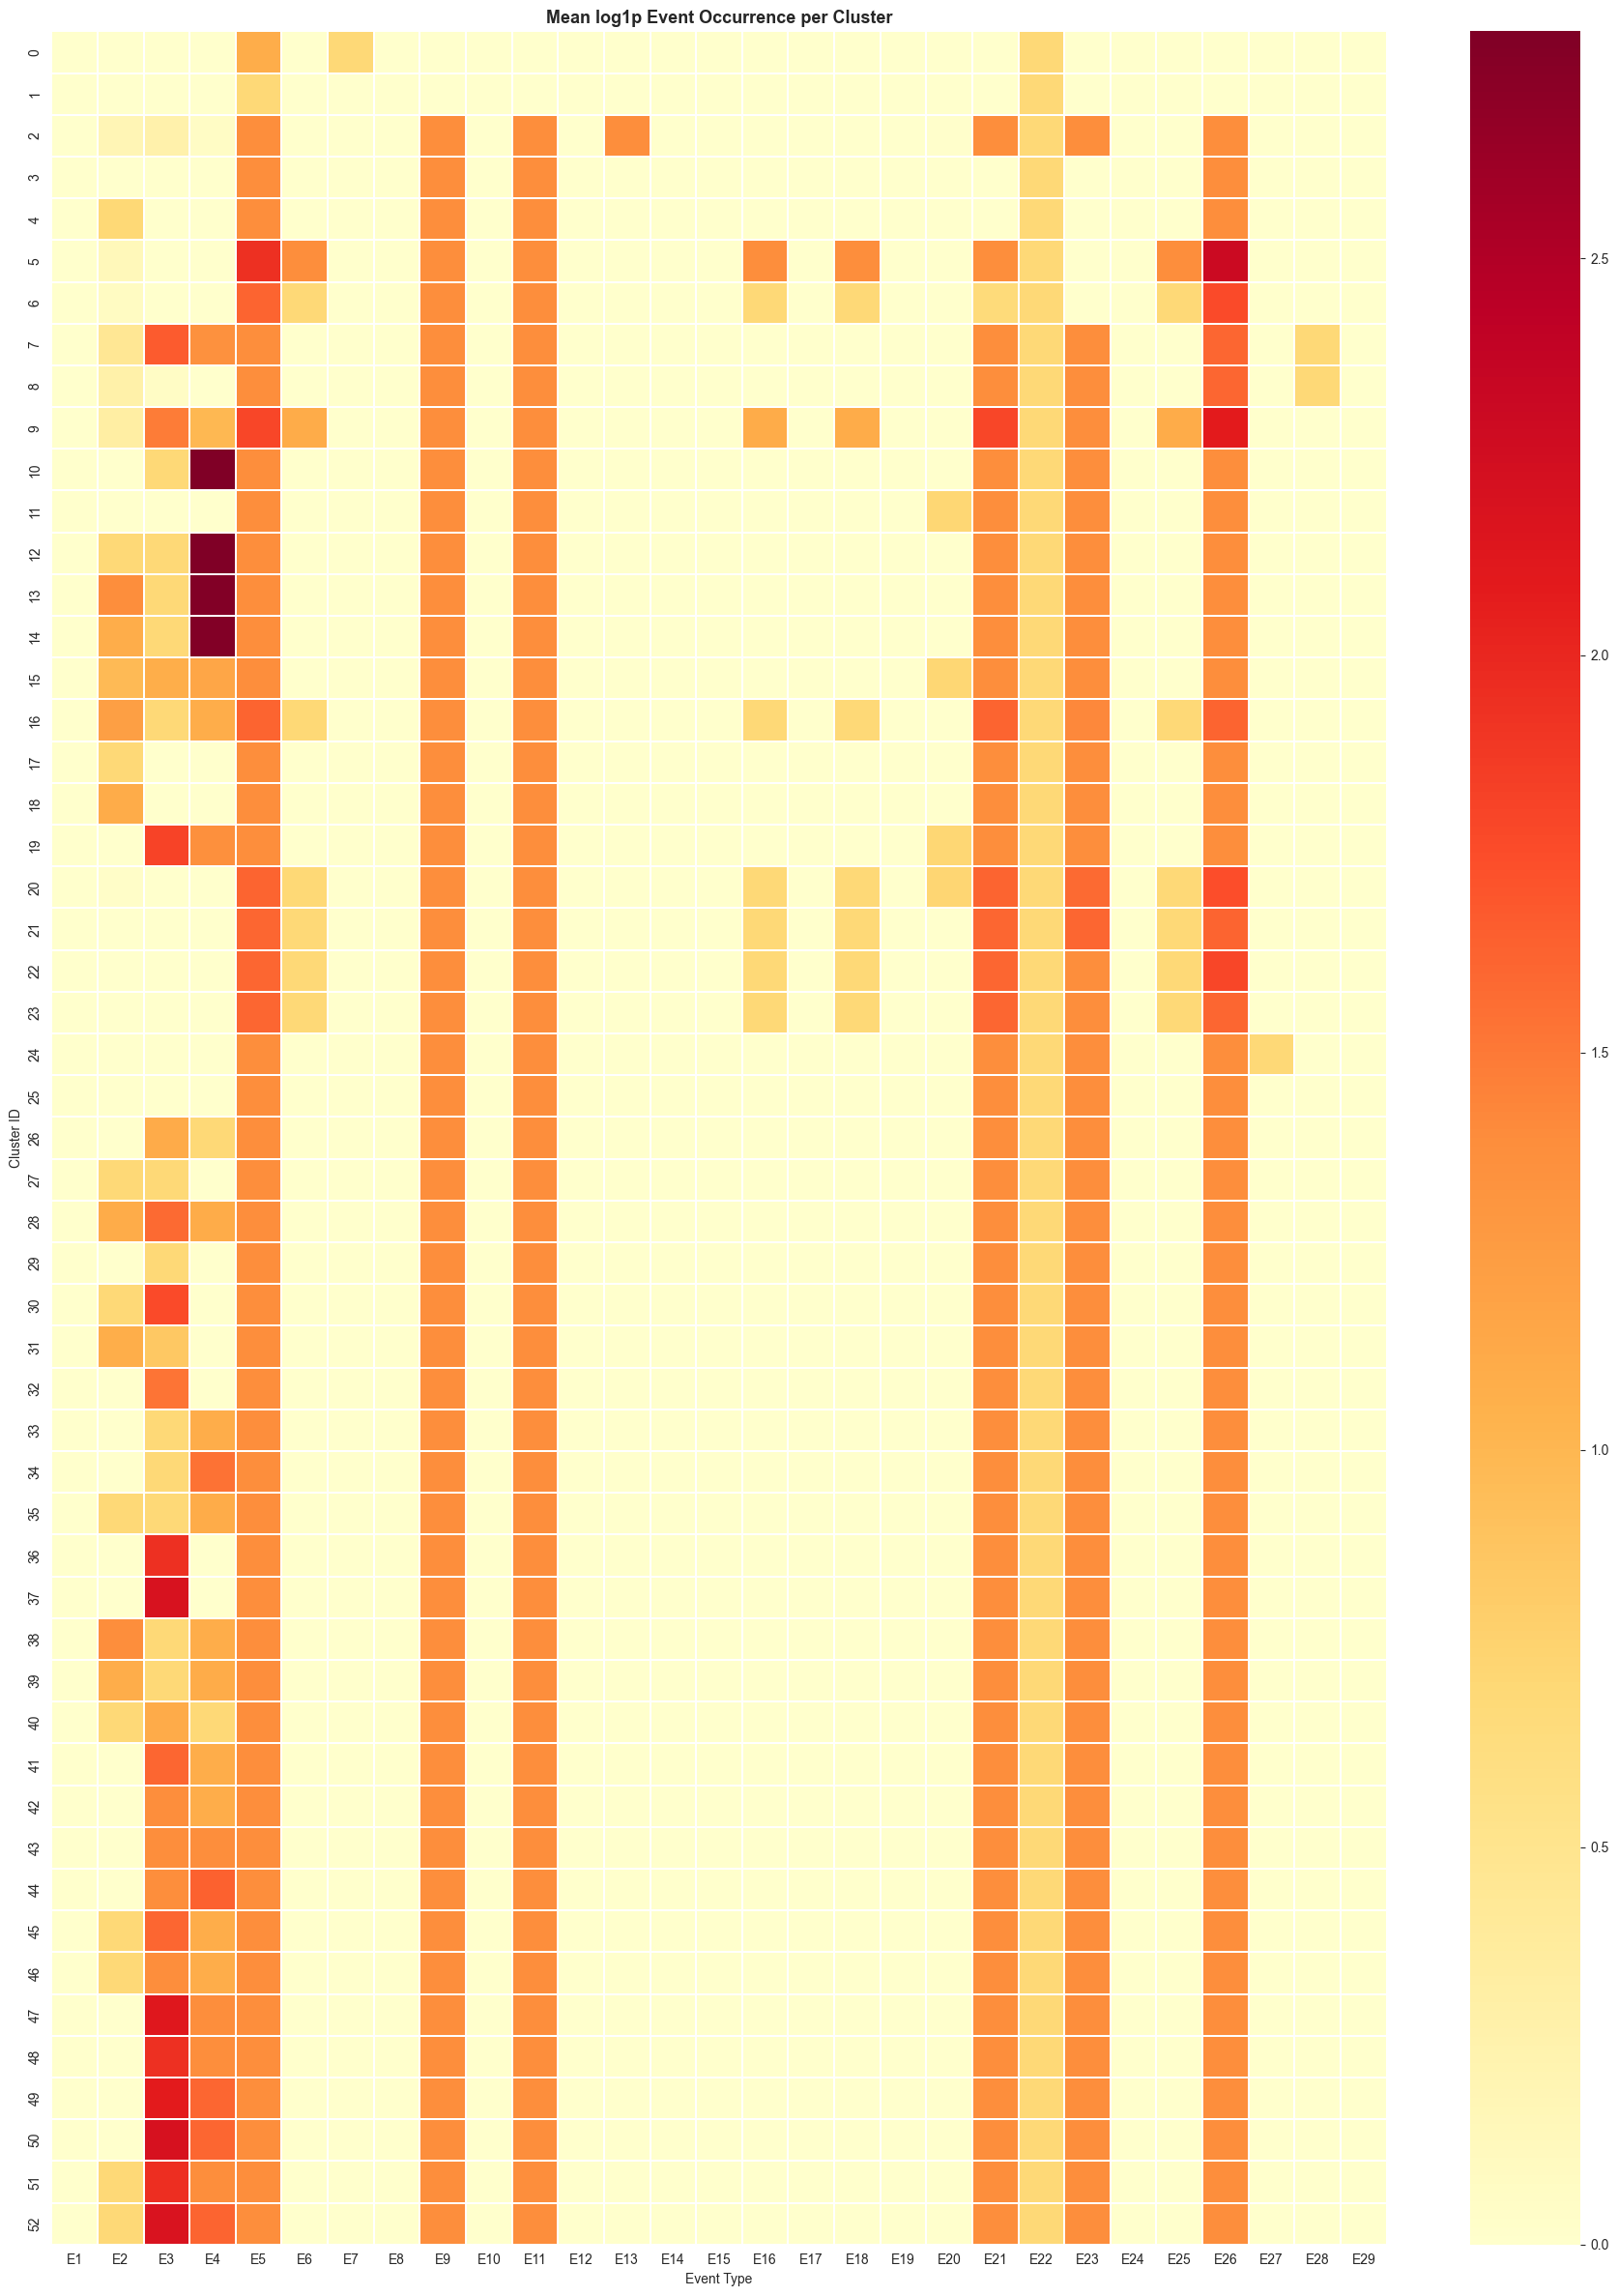

In [30]:
clustered = occ_s[occ_s["cluster"] != -1].copy()
profile_df = clustered.groupby("cluster")[EVENT_COLS].mean().apply(np.log1p)

fig, ax = plt.subplots(figsize=(18, max(4, len(profile_df) * 0.45)))
sns.heatmap(
    profile_df, ax=ax, cmap="YlOrRd", linewidths=0.3,
    annot=len(profile_df) <= 20, fmt=".1f",
)
ax.set_title("Mean log1p Event Occurrence per Cluster", fontweight="bold", fontsize=13)
ax.set_xlabel("Event Type")
ax.set_ylabel("Cluster ID")
plt.tight_layout()
plt.show()

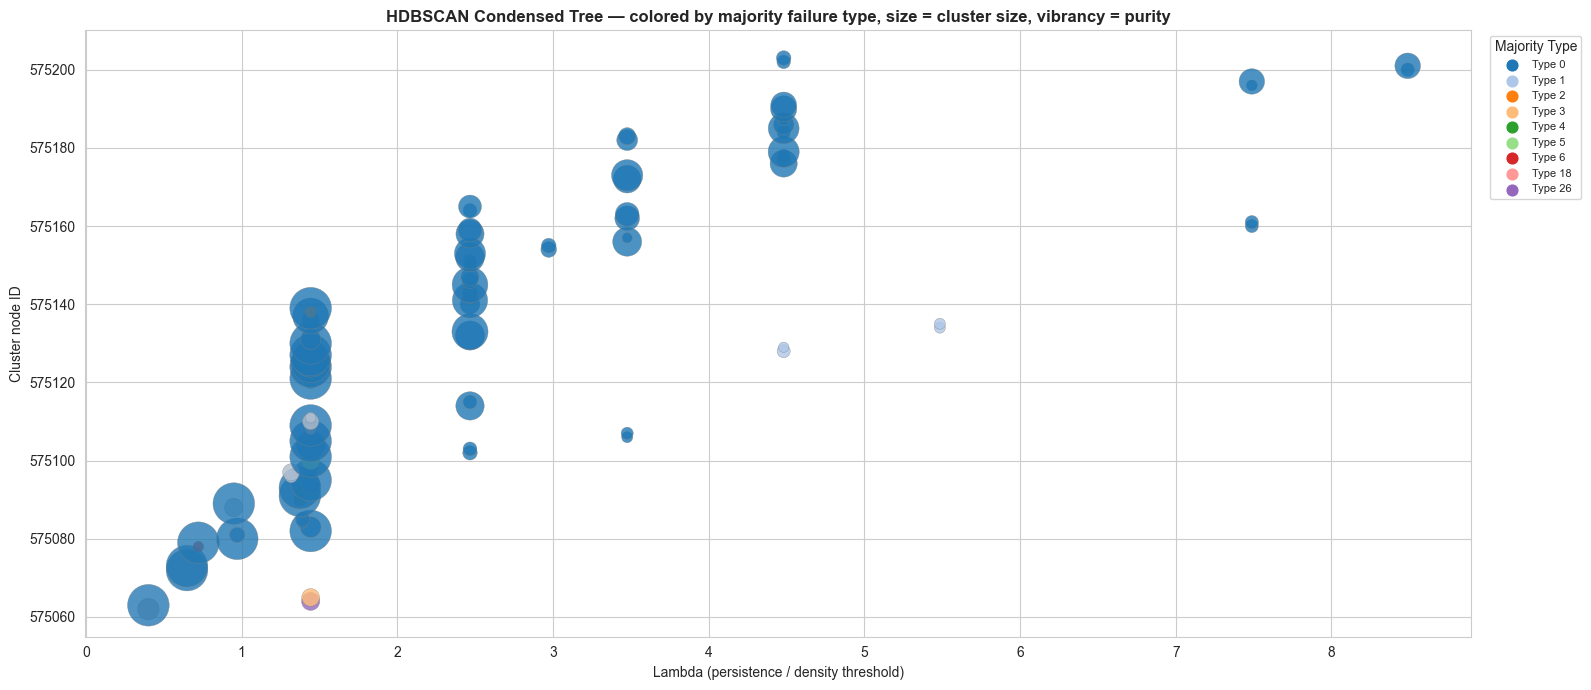

In [35]:
tree_df = best_clusterer.condensed_tree_.to_pandas()
cluster_tree = tree_df[tree_df['child_size'] > 1].copy()

# For each cluster node, find which points belong to it and compute majority class
def get_cluster_stats(node, tree_df, y_type, n_points):
    """Get all leaf points under a given node in the condensed tree."""
    points = []
    stack = [node]
    while stack:
        current = stack.pop()
        children = tree_df[tree_df['parent'] == current]
        leaf_points = children[children['child_size'] == 1]['child'].astype(int)
        points.extend(leaf_points.tolist())
        internal = children[children['child_size'] > 1]['child']
        stack.extend(internal.tolist())
    return np.array(points)

majority_type = []
majority_frac = []
cluster_sizes = []

for node in cluster_tree['child'].values:
    pts = get_cluster_stats(node, tree_df, y_type_s, len(y_type_s))
    pts = pts[pts < len(y_type_s)]  # bounds check
    if len(pts) == 0:
        majority_type.append(-1)
        majority_frac.append(0)
        cluster_sizes.append(0)
        continue
    counts = Counter(y_type_s[pts])
    top_type, top_count = counts.most_common(1)[0]
    majority_type.append(top_type)
    majority_frac.append(top_count / len(pts))
    cluster_sizes.append(len(pts))

cluster_tree['majority_type'] = majority_type
cluster_tree['majority_frac'] = majority_frac
cluster_tree['true_size'] = cluster_sizes

# Build RGBA colors — hue by type, saturation by majority fraction
unique_types = sorted(set(majority_type))
palette = sns.color_palette("tab20", len(unique_types))
type_to_color = {t: palette[i] for i, t in enumerate(unique_types)}

colors = []
for t, frac in zip(majority_type, majority_frac):
    r, g, b = type_to_color[t]
    # Blend toward gray based on how weak the majority is
    # frac=1.0 -> full color, frac=0.5 -> very washed out
    saturation = (frac - 0.5) / 0.5  # rescale 0.5-1.0 to 0.0-1.0
    saturation = max(0, saturation)
    gray = 0.7
    r = r * saturation + gray * (1 - saturation)
    g = g * saturation + gray * (1 - saturation)
    b = b * saturation + gray * (1 - saturation)
    colors.append((r, g, b))

fig, ax = plt.subplots(figsize=(16, 7))
scatter = ax.scatter(
    cluster_tree['lambda_val'],
    cluster_tree['child'],
    c=colors,
    s=np.sqrt(cluster_tree['true_size']).clip(upper=300) * 3,
    alpha=0.8,
    linewidths=0.3,
    edgecolors='gray'
)

# Legend for failure types
for t in unique_types:
    r, g, b = type_to_color[t]
    ax.scatter([], [], c=[(r, g, b)], label=f'Type {t}', s=60)

ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, title='Majority Type')
ax.set_xlabel('Lambda (persistence / density threshold)')
ax.set_ylabel('Cluster node ID')
ax.set_title('HDBSCAN Condensed Tree — colored by majority failure type, size = cluster size, vibrancy = purity', fontweight='bold')
plt.tight_layout()
plt.show()

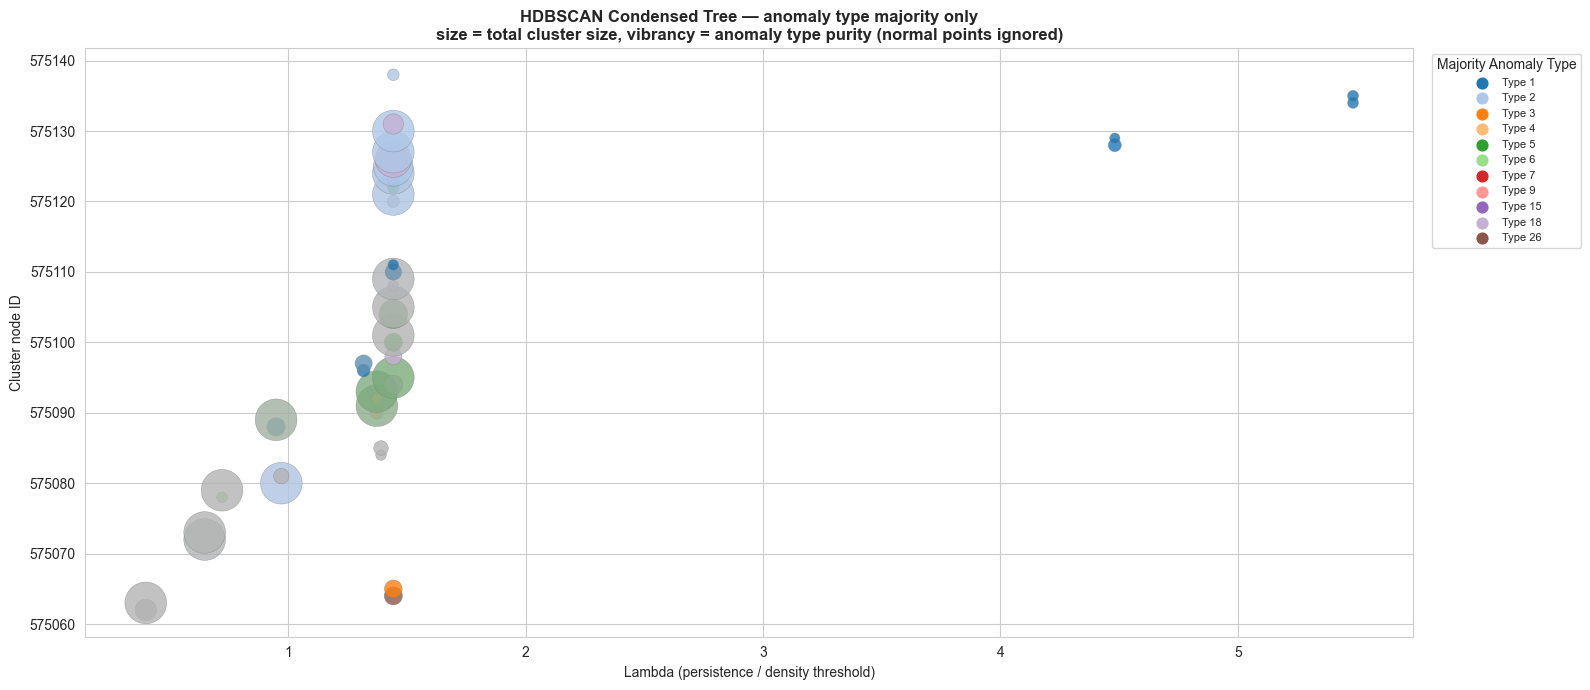

In [36]:
tree_df = best_clusterer.condensed_tree_.to_pandas()
cluster_tree = tree_df[tree_df['child_size'] > 1].copy()

def get_cluster_stats(node, tree_df, n_points):
    points = []
    stack = [node]
    while stack:
        current = stack.pop()
        children = tree_df[tree_df['parent'] == current]
        leaf_points = children[children['child_size'] == 1]['child'].astype(int)
        points.extend(leaf_points.tolist())
        internal = children[children['child_size'] > 1]['child']
        stack.extend(internal.tolist())
    return np.array(points)

majority_type = []
majority_frac = []
cluster_sizes = []
anomaly_fracs = []

for node in cluster_tree['child'].values:
    pts = get_cluster_stats(node, tree_df, len(y_type_s))
    pts = pts[pts < len(y_type_s)]

    if len(pts) == 0:
        majority_type.append(-1)
        majority_frac.append(0)
        cluster_sizes.append(0)
        anomaly_fracs.append(0)
        continue

    # Filter to anomalies only for type majority calculation
    anom_mask = y_bin_s[pts] == 1
    anom_pts = pts[anom_mask]
    anomaly_frac = anom_mask.mean()
    anomaly_fracs.append(anomaly_frac)
    cluster_sizes.append(len(pts))

    if len(anom_pts) == 0:
        # Entirely normal cluster — mark as type -1
        majority_type.append(-1)
        majority_frac.append(0)
    else:
        counts = Counter(y_type_s[anom_pts])
        top_type, top_count = counts.most_common(1)[0]
        majority_type.append(top_type)
        majority_frac.append(top_count / len(anom_pts))  # purity among anomalies only

cluster_tree['majority_type'] = majority_type
cluster_tree['majority_frac'] = majority_frac
cluster_tree['true_size'] = cluster_sizes
cluster_tree['anomaly_frac'] = anomaly_fracs

# Drop clusters that are entirely normal (no anomalies)
cluster_tree = cluster_tree[cluster_tree['majority_type'] != -1]

# Colors
unique_types = sorted(set(cluster_tree['majority_type']))
palette = sns.color_palette("tab20", len(unique_types))
type_to_color = {t: palette[i] for i, t in enumerate(unique_types)}

colors = []
for t, frac in zip(cluster_tree['majority_type'], cluster_tree['majority_frac']):
    r, g, b = type_to_color[t]
    saturation = max(0, (frac - 0.5) / 0.5)
    gray = 0.7
    r = r * saturation + gray * (1 - saturation)
    g = g * saturation + gray * (1 - saturation)
    b = b * saturation + gray * (1 - saturation)
    colors.append((r, g, b))

fig, ax = plt.subplots(figsize=(16, 7))
ax.scatter(
    cluster_tree['lambda_val'],
    cluster_tree['child'],
    c=colors,
    s=np.sqrt(cluster_tree['true_size']).clip(upper=300) * 3,
    alpha=0.8,
    linewidths=0.3,
    edgecolors='gray'
)

for t in unique_types:
    r, g, b = type_to_color[t]
    ax.scatter([], [], c=[(r, g, b)], label=f'Type {t}', s=60)

ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, title='Majority Anomaly Type')
ax.set_xlabel('Lambda (persistence / density threshold)')
ax.set_ylabel('Cluster node ID')
ax.set_title(
    'HDBSCAN Condensed Tree — anomaly type majority only\n'
    'size = total cluster size, vibrancy = anomaly type purity (normal points ignored)',
    fontweight='bold'
)
plt.tight_layout()
plt.show()

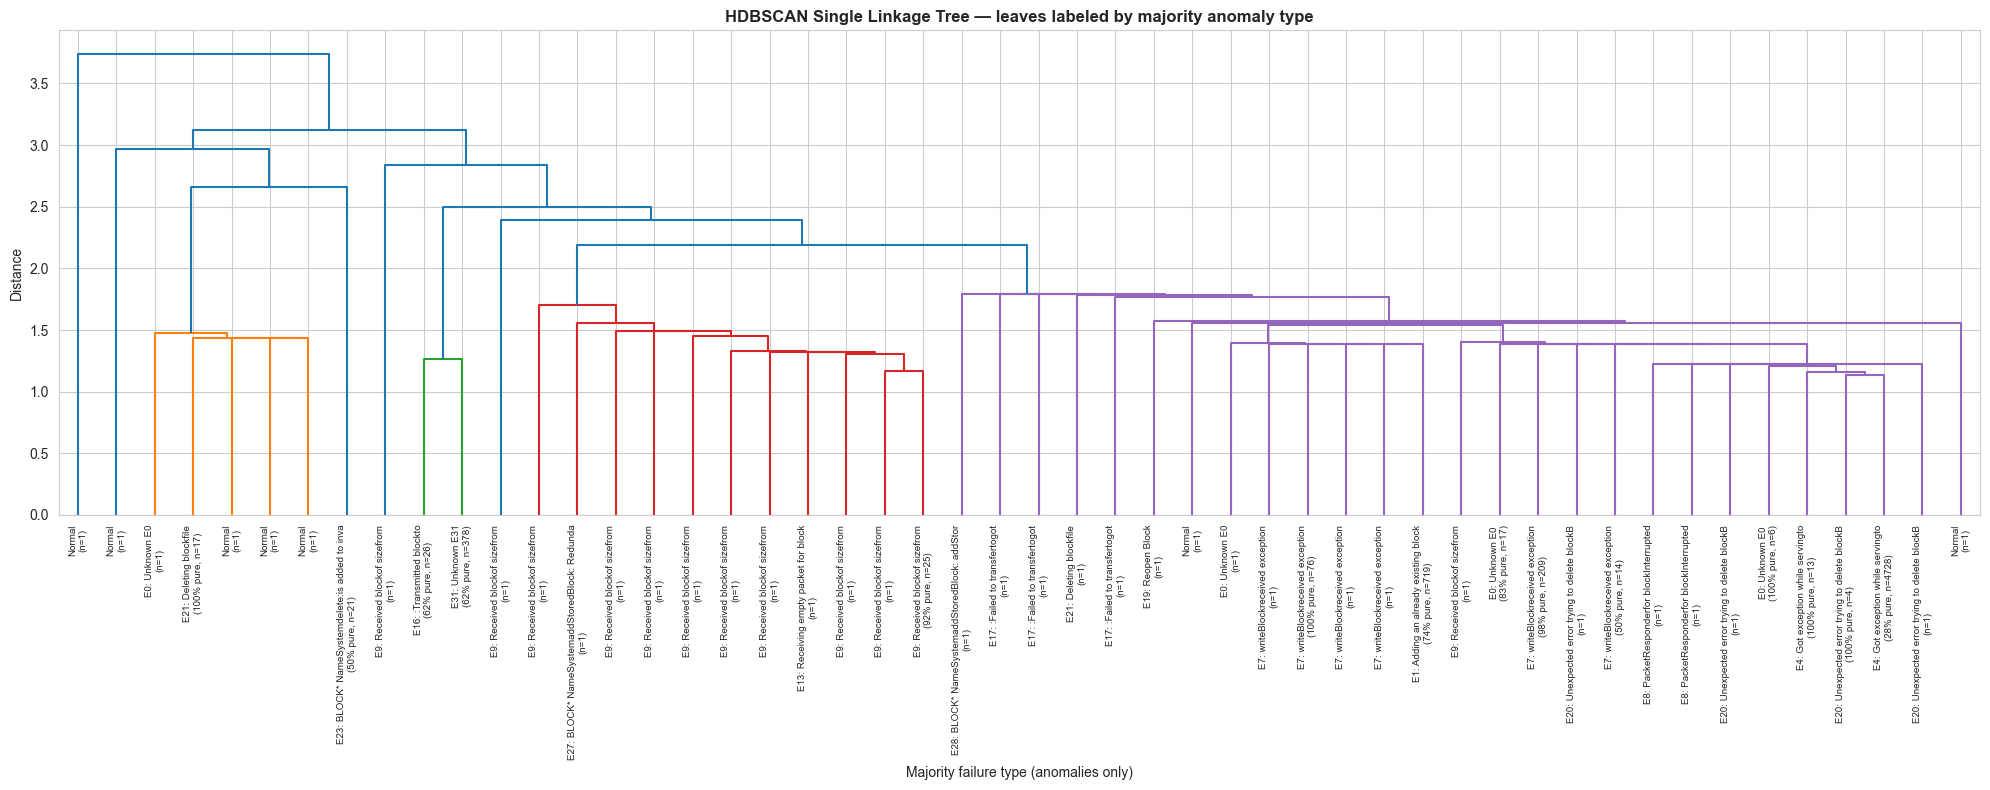

In [61]:
from scipy.cluster.hierarchy import dendrogram

tree_df = best_clusterer.condensed_tree_.to_pandas()
cluster_tree = tree_df[tree_df['child_size'] > 1].copy()

def get_cluster_stats(node, tree_df, n_points):
    points = []
    stack = [node]
    while stack:
        current = stack.pop()
        children = tree_df[tree_df['parent'] == current]
        leaf_points = children[children['child_size'] == 1]['child'].astype(int)
        points.extend(leaf_points.tolist())
        internal = children[children['child_size'] > 1]['child']
        stack.extend(internal.tolist())
    return np.array(points)

majority_type = []
majority_frac = []
cluster_sizes = []
anomaly_fracs = []

for node in cluster_tree['child'].values:
    pts = get_cluster_stats(node, tree_df, len(y_type_s))
    pts = pts[pts < len(y_type_s)]

    if len(pts) == 0:
        majority_type.append(-1)
        majority_frac.append(0)
        cluster_sizes.append(0)
        anomaly_fracs.append(0)
        continue

    # Filter to anomalies only for type majority calculation
    anom_mask = y_bin_s[pts] == 1
    anom_pts = pts[anom_mask]
    anomaly_frac = anom_mask.mean()
    anomaly_fracs.append(anomaly_frac)
    cluster_sizes.append(len(pts))

    if len(anom_pts) == 0:
        # Entirely normal cluster — mark as type -1
        majority_type.append(-1)
        majority_frac.append(0)
    else:
        counts = Counter(y_type_s[anom_pts])
        top_type, top_count = counts.most_common(1)[0]
        majority_type.append(top_type)
        majority_frac.append(top_count / len(anom_pts))  # purity among anomalies only

cluster_tree['majority_type'] = majority_type
cluster_tree['majority_frac'] = majority_frac
cluster_tree['true_size'] = cluster_sizes
cluster_tree['anomaly_frac'] = anomaly_fracs

# Drop clusters that are entirely normal (no anomalies)
# cluster_tree = cluster_tree[cluster_tree['majority_type'] != -1]

linkage_matrix = best_clusterer.single_linkage_tree_.to_numpy()
n_points = len(y_type_s)

def get_leaves(node, linkage_matrix, n_points, max_depth=50, depth=0):
    if depth >= max_depth or node < n_points:
        return [node] if node < n_points else []
    idx = node - n_points
    if idx >= len(linkage_matrix):
        return []
    left  = int(linkage_matrix[idx, 0])
    right = int(linkage_matrix[idx, 1])
    return (get_leaves(left,  linkage_matrix, n_points, max_depth, depth+1) + 
            get_leaves(right, linkage_matrix, n_points, max_depth, depth+1))

node_to_label = {}
for i in range(len(linkage_matrix)):
    node_id = n_points + i
    pts = np.array(get_leaves(node_id, linkage_matrix, n_points))
    pts = pts[pts < n_points]

    anom_pts = pts[y_bin_s[pts] == 1] if len(pts) > 0 else np.array([])
    if len(anom_pts) == 0:
        label = 'Normal'
    else:
        counts = Counter(y_type_s[anom_pts])
        top_type, top_count = counts.most_common(1)[0]
        frac = top_count / len(anom_pts)
        name = encoded_to_label.get(int(top_type), f'Type {top_type}')
        label = f"{name}\n({frac:.0%} pure, n={len(pts)})"

    node_to_label[node_id] = label

def leaf_label_func(node_id):
    if node_id in node_to_label:
        return node_to_label[node_id]
    
    if node_id < n_points:
        if y_bin_s[node_id] == 0:  # binary 0 = normal
            return 'Normal\n(n=1)'
        t = int(y_type_s[node_id])
        name = encoded_to_label.get(t, f'Type {t}')
        return f"{name}\n(n=1)"
    
    # Fallback for missed merged nodes
    pts = np.array(get_leaves(node_id, linkage_matrix, n_points))
    pts = pts[pts < n_points]
    anom_pts = pts[y_bin_s[pts] == 1] if len(pts) > 0 else np.array([])
    if len(anom_pts) == 0:  # fixed: was == -1
        return f'Normal\n(n={len(pts)})'
    counts = Counter(y_type_s[anom_pts])
    top_type, top_count = counts.most_common(1)[0]
    frac = top_count / len(anom_pts)
    name = encoded_to_label.get(int(top_type), f'Type {top_type}')
    return f"{name}\n({frac:.0%} pure, n={len(pts)})"

fig, ax = plt.subplots(figsize=(20, 8))
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',
    p=50,
    ax=ax,
    leaf_rotation=90,
    leaf_font_size=7,
    color_threshold=0.5 * max(linkage_matrix[:, 2]),
    leaf_label_func=leaf_label_func,
)
ax.set_title('HDBSCAN Single Linkage Tree — leaves labeled by majority anomaly type', fontweight='bold')
ax.set_xlabel('Majority failure type (anomalies only)')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

## 11. Export for LLM Summarisation Pipeline

In [ ]:
# Load event templates for human-readable descriptions in the LLM prompt
templates = pd.read_csv(DATA_DIR / "HDFS.log_templates.csv")
templates.columns = [c.strip() for c in templates.columns]
eid_col  = next(c for c in templates.columns if "event" in c.lower() and "id" in c.lower())
etpl_col = next(c for c in templates.columns if "template" in c.lower())
event_template_map = dict(zip(templates[eid_col], templates[etpl_col]))
print(f"Loaded {len(event_template_map)} event templates")

In [ ]:
OUTPUT_PATH = Path("../data/clusters_occurrence.json")
OUTPUT_PATH.parent.mkdir(exist_ok=True)

output_records = []
for cid in sorted(occ_s["cluster"].unique()):
    sub = occ_s[occ_s["cluster"] == cid]
    n_anom = (sub["Label"] == "Fail").sum()
    mean_counts = sub[EVENT_COLS].mean().round(2)

    event_profile = sorted(
        [
            {
                "event_id": eid,
                "mean_occurrences": float(mean_counts[eid]),
                "template": event_template_map.get(eid, "Unknown"),
            }
            for eid in EVENT_COLS
            if mean_counts[eid] > 0.01
        ],
        key=lambda x: -x["mean_occurrences"],
    )

    output_records.append({
        "cluster_id":          int(cid),
        "is_noise":            cid == -1,
        "n_incidents":         len(sub),
        "n_anomaly":           int(n_anom),
        "anomaly_frac":        round(n_anom / len(sub), 3),
        "dominant_type":       str(sub["Type"].value_counts(dropna=False).index[0]),
        "block_ids":           sub["BlockId"].tolist(),
        "event_profile":       event_profile,
        "embedding_centroid":  X_reduced[sub.index].mean(axis=0).tolist(),
    })

with open(OUTPUT_PATH, "w") as f:
    json.dump(output_records, f, indent=2)

real = sum(1 for r in output_records if not r["is_noise"])
print(f"Exported {real} clusters + 1 noise record to {OUTPUT_PATH}")
print("\nSample cluster record:")
sample = next(r for r in output_records if not r["is_noise"])
print(json.dumps({k: v for k, v in sample.items() if k != "block_ids"}, indent=2))

---
## 12. Findings & Metric Guide

| Metric | What it means for your pipeline |
|---|---|
| `purity_type` ↑ | Each cluster is dominated by one failure mode → LLM gets coherent incidents |
| `anomaly_recall` ↑ | Anomalies land in anomaly-dominated clusters → LLM is pointed at the right incidents |
| `noise_frac` ↓ | Fewer incidents unclustered → fewer incidents the LLM never sees |
| `v_measure` ↑ | Harmonic mean of homogeneity + completeness — single-number summary |

### Key data insights from exploration
- **`Type` = failure mode** — NaN is Normal/Success. 26 distinct numeric codes are distinct fault categories. Your LLM should produce a separate summary per Type.
- **E29 is a perfect anomaly discriminator** — `PendingReplicationMonitor timed out` appears in 46 Fail blocks and zero Normal blocks. Any cluster with E29 > 0 is an anomaly cluster.
- **E3 must be log-normalized** — up to 203 occurrences per block; raw counts will cause Normal blocks to cluster by write volume, not failure type.
- **Latency** — Fail blocks tend to have higher latency. Adding it as a feature (`log1p+lat`) may help separate timing-based failure types.

### Recommended next steps
1. **Scale up** — run on all 575k incidents with `umap.UMAP(low_memory=True)`. HDBSCAN is fine at full scale with `core_dist_n_jobs=-1`.
2. **Tune `min_cluster_size` to expected type size** — there are ~16,838 anomalies across 26 types → ~648 per type. At full scale, `min_cluster_size=500` is a principled starting point.
3. **Evaluate per Type code** — check whether each known Type maps to a single cluster. Splitting means `min_cluster_size` is too small; merging means it's too large.
4. **Wire to LLM** — pass `event_profile` (which events fired and how often, with readable templates) as the context. This is far more compact and interpretable than raw log text.